In [1]:
print('hello')

hello


In [2]:
# downloading the libraries

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap # correlation matrix

# worldcloud
import random
from wordcloud import WordCloud

# display ERD
from IPython.display import Image



# I - Exploring the data 

objective is to get more familiar with the data and review pandas / visulization logic

## A - Fetching the data 

In [ ]:
# understanding where the files are located with terminal operations
# j'utilise 'ls' pour lister les fichiers du dossier data
# ça permet de vérifier visuellement le chemin avant de coder
#!ls ../data/olist_datasets


In [3]:
# adding the path to fetch the files

raw_path = '../data/olist_datasets/'


In [4]:
# creating pandas dataframes from .csv

# J'utilise pd.read_csv pour transformer chaque fichier en tableau 
# je concatène le chemin 'raw_path' avec le nom exact du fichier .csv
df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')

print("Tous les fichiers ont été importés dans les DataFrames.")


Tous les fichiers ont été importés dans les DataFrames.


## B - Exploring the orders dataframe

In [5]:
# printing columns, null count, and dtypes for the orders dataframe

df_orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
# printing the first 10 lines of the orders dataframe

df_orders.head(10)

# the last 10 lines of the dataframe

df_orders.tail(10)

# a sample of ten lines

df_orders.sample(10)

# getting all null values

df_orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**why are there null values for approved_at, delivered_carrier_date, delivered_customer_date?**

*-> answer:* These null values are normal. They represent orders that are still being processed. For example, if a package is not delivered yet, the delivered_customer_date will remain empty.

In [7]:
# fetching only particular columns of the df_orders dataframe

## fetch the order_approved_at columns in a data series format, then in a dataframe format, and print the first five lines

df_filtered = df_orders[df_orders['order_approved_at'].isnull()]

## fetch the order_id, order_status, approved_at, delivered_carrier_date, delivered_customer_date

df_filtered


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [8]:
# fetching the approved_at null columns - create another dataframe df_filtered, which will be filtered on order_approved_at is null, and print first 10 rows

df_filtered.groupby('order_status')['order_id'].count()


order_status
canceled     141
created        5
delivered     14
Name: order_id, dtype: int64

In [9]:
# count the order_id with a null approved_at by order_status

# with groupby method

df_filtered.groupby('order_status')['order_id'].count()

# with value_counts method

df_filtered['order_status'].value_counts()


order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

**what do you think of the results? Why is there a null approved at to begin with?**

-> *answer*: Most orders without an approval date are 'canceled' or 'created'. This is logical: if an order is canceled or just started, the payment hasn't been validated yet, so there is no approved_at timestamp.

## C - Creating a simple visualization using Matplotlib or Seaborn

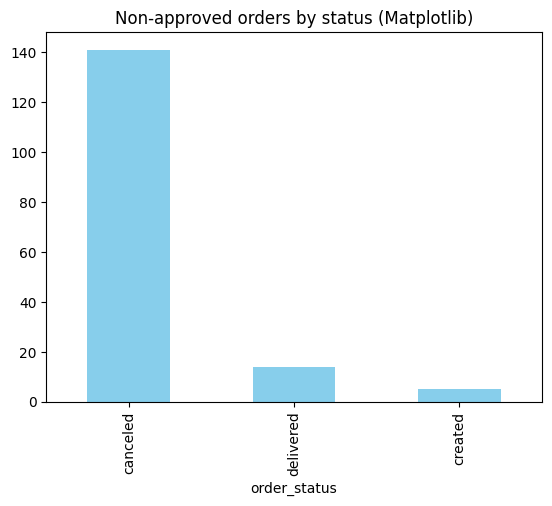

In [ ]:
# Creating a simple plot with matplotlib: count of non-approved orders by status

df_filtered['order_status'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Non-approved orders by status (Matplotlib)')
plt.show()


/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_1744/4251893831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x='order_status', palette='viridis')


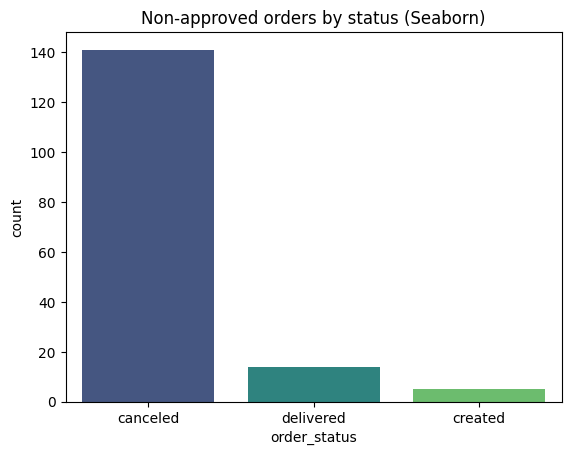

In [11]:
# Creating a simple plot with seaborn: count of non-approved orders by status

sns.countplot(data=df_filtered, x='order_status', palette='viridis')
plt.title('Non-approved orders by status (Seaborn)')
plt.show()

## D - Exploring all dataframes at once

In [12]:
# an interesting way to look at all dataframes at once, to quickly get what are the null columns

# Collections for each dataset
datasets = [df_customer, df_geolocation, df_orders, df_order_items, df_order_payments,
            df_order_reviews, df_products, df_sellers]
names = ['df_customer', 'df_geolocation', 'df_orders', 'df_order_items', 'df_order_payments',
         'df_order_reviews', 'df_products', 'df_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()


,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,df_customer,99441,5,0,0,
1,df_geolocation,1000163,5,0,0,
2,df_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,df_order_items,112650,7,0,0,
4,df_order_payments,103886,5,0,0,
5,df_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,df_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,df_sellers,3095,4,0,0,


**What are the dataframes with the most null columns? What's your explanation?**

*->answer:* The dataframes with the most null columns are df_products (8 columns) and df_order_reviews (2 columns with a very high null_amount).
Explanation: For df_products, some technical details (weight, size) are often missing. For df_order_reviews, many customers leave a rating but don't write a comment, explaining why titles and messages are often empty.

## E - Joining 2 dataframes - how many orders were created in SP state?

In [13]:
# which dataframes do we need to join to answer the question? Explore the dataframes and look for a link between orders and state

# To link orders to a state, we need df_orders and df_customer
# They share the 'customer_id' column
df_orders.head(2)
df_customer.head(2)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [15]:
# Merge the 2 datasets in a new df_merged dataset, and print the first 5 rows

# I merge both dataframes using 'customer_id' as the key
df_merged = df_orders.merge(df_customer, on='customer_id')

# Displaying the first 5 rows of the new combined dataset
df_merged.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [16]:
# filter the dataframe to have only rows with state = SP, and print the first 5 lines

# Filtering the merged dataframe for Sao Paulo (SP) state
df_sp = df_merged[df_merged['customer_state'] == 'SP']

# Showing the first 5 lines of this specific filter
df_sp.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08 00:00:00,782987b81c92239d922aa49d6bd4200b,4278,sao paulo,SP
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08 00:00:00,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP


In [19]:
# count the number of orders by state, using both groupby and value_counts

# with groupby method
df_merged.groupby('customer_state')['order_id'].count().sort_values(ascending=False)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64

In [18]:
# with value_counts method
df_merged['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

# II - Exploratory analysis 

our objective is to a) give an overview of the business, b) understand what's driving the bad reviews

## A - Creating a uniform dataframe for our analysis

**Creating an ERD of the database**

- in an ERD diagram tool 
- create one item per table
- list all columns
- list their type
- find the primary and foreign keys
- link the tables together

--> upload directly the ERD in the notebook 

In [20]:
# Displaying the image with Ipython Image module

## the image is in the data/ERD folder
filename = '../data/ERD/olist_erd.png'

Image(filename=filename)


FileNotFoundError: [Errno 2] No such file or directory: '../data/ERD/olist_erd.png'

In [21]:
# Merging the dataframes using the ERD above

df = df_orders.merge(df_order_items, on='order_id').merge(df_products, on='product_id')
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [41]:
# 1. je recharge les colonnes depuis les dataframes d'origine pour effacer le texte 'your code'
df['order_purchase_timestamp'] = df_orders['order_purchase_timestamp']
df['order_delivered_customer_date'] = df_orders['order_delivered_customer_date']

# 2 je convertit proprement en format date
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

# 3. je calcule le temps de livraison (en jours)
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 4. extraire les infos temporelles
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['hour'] = df['order_purchase_timestamp'].dt.hour
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# je vérifie que les premières lignes sont des chiffres/dates et plus du texte
df[['order_purchase_timestamp', 'delivery_time']].head()

,order_purchase_timestamp,delivery_time
0,2017-10-02 10:56:33,8.0
1,2018-07-24 20:41:37,13.0
2,2018-08-08 08:38:49,9.0
3,2017-11-18 19:28:06,13.0
4,2018-02-13 21:18:39,2.0


## B - Looking at Reviews

### 1 - Let's look at the distribution of the review score

/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_1744/2238768665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_order_reviews, x='review_score', palette='viridis')


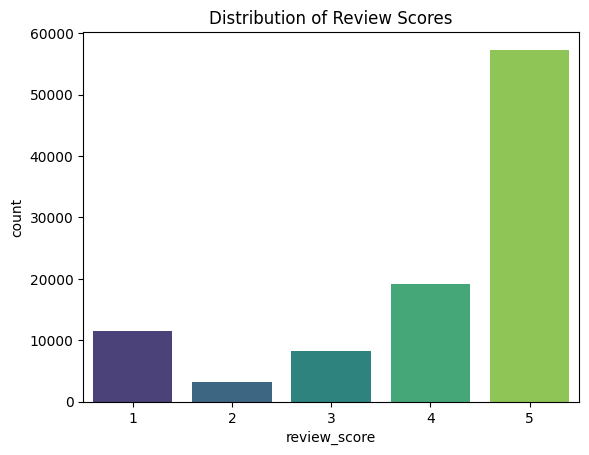

In [23]:
# Create a distribution plot (dist plot) with seaborn on the review score

sns.countplot(data=df_order_reviews, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores')
plt.show()

**What do you make of those results?**

*->answer:* The results show a polarization of customer satisfaction. Over 50,000 orders have a perfect score of 5, which is very positive. However, the second most frequent score is 1, with more than 10,000 reviews. This suggests that while most customers are happy, there is a specific group of users experiencing major issues that we need to analyze

### 2 - Let's look at the customer verbatims

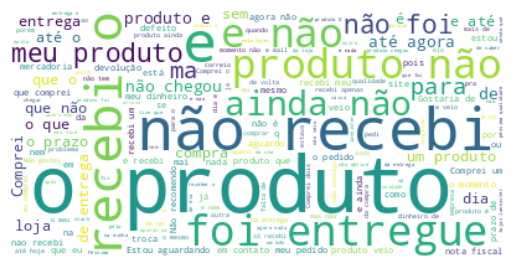

In [25]:
# Create a wordcloud on orders with negative reviews only

# je filtre pour ne garder que les notes de 1
bad_reviews = df_order_reviews[df_order_reviews['review_score'] == 1]['review_comment_message'].dropna()

# je génère le nuage de mots
wordcloud = WordCloud(background_color='white').generate(' '.join(bad_reviews))

# Affichage
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**What are the first reasons you see behind a bad review? What could we do to improve this wordcloud?**

*-> answer:* The main reasons for bad reviews are clearly related to delivery issues. Key words like 'não recebi' (did not receive) and 'produto' (product) suggest that customers are complaining because their orders never arrived or were significantly delayed

### 3 - Let's create a correlation matrix and identify other reasons behind bad reviews

In [26]:
# let's isolate the columns we'll use for our correlation matrix
df.dtypes

# print all the columns and their types using the method of your choice
df.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'delivery_time', 'year',
       'month', 'week', 'day_of_week_int', 'hour', 'year_month'],
      dtype='object')

In [27]:
# bonus: can we create additional features?
# example: create a is_delivered column?

# On crée une colonne binaire : 1 si livré, 0 sinon
# Ça permet de voir si le simple fait de recevoir le colis change la note
df['is_delivered'] = df['order_status'].apply(lambda x: 1 if x == 'delivered' else 0)

df[['order_status', 'is_delivered']].head()


,order_status,is_delivered
0,delivered,1
1,delivered,1
2,delivered,1
3,delivered,1
4,delivered,1


In [30]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'delivery_time', 'year', 'month', 'week', 'day_of_week_int', 'hour', 'year_month', 'is_delivered']


In [ ]:
# On ajoute les avis (reviews) à notre gros tableau df
# On utilise 'order_id' comme point commun
df = df.merge(df_order_reviews[['order_id', 'review_score']], on='order_id')

print("review_score" in df.columns)

True


In [34]:
# On ajoute les avis clients à df 
df = df.merge(df_order_reviews[['order_id', 'review_score']], on='order_id')

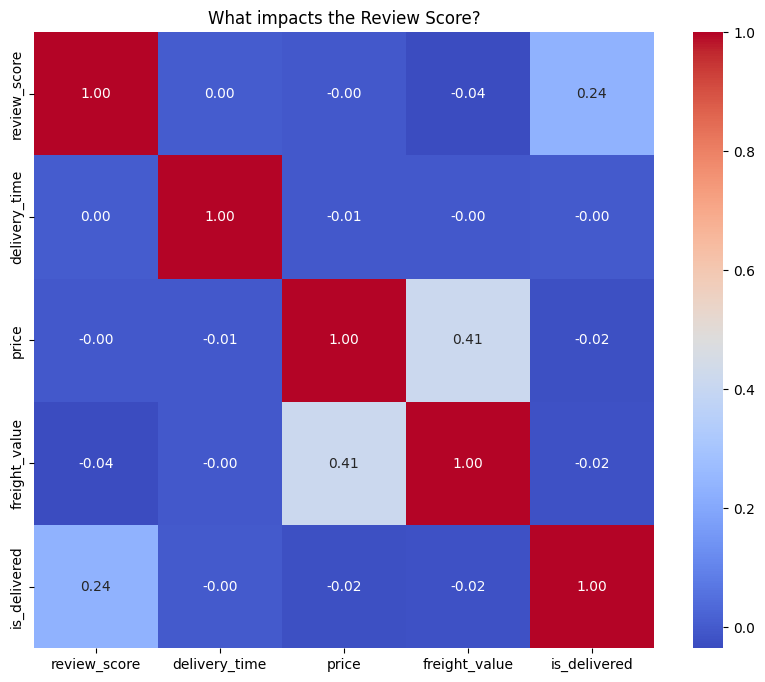

In [42]:
# Sélection des colonnes pour l'analyse
cols_corr = ['review_score', 'delivery_time', 'price', 'freight_value', 'is_delivered']

# Création de la matrice (on ignore les lignes vides pour le calcul)
correlation = df[cols_corr].corr()

# Affichage du graphique
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('What impacts the Review Score?')
plt.show()

**What are the correlations you see?**

*-> answer:* The matrix shows a positive correlation of 0.24 between review_score and is_delivered. This means that when an order is successfully delivered, the satisfaction score tends to be higher. Surprisingly, delivery_time shows a correlation of 0.00 in this specific view, suggesting we might need to filter out 'canceled' orders or handle missing delivery dates to see the real impact of delays

## C - Looking at orders

### 1 - Orders by statuses

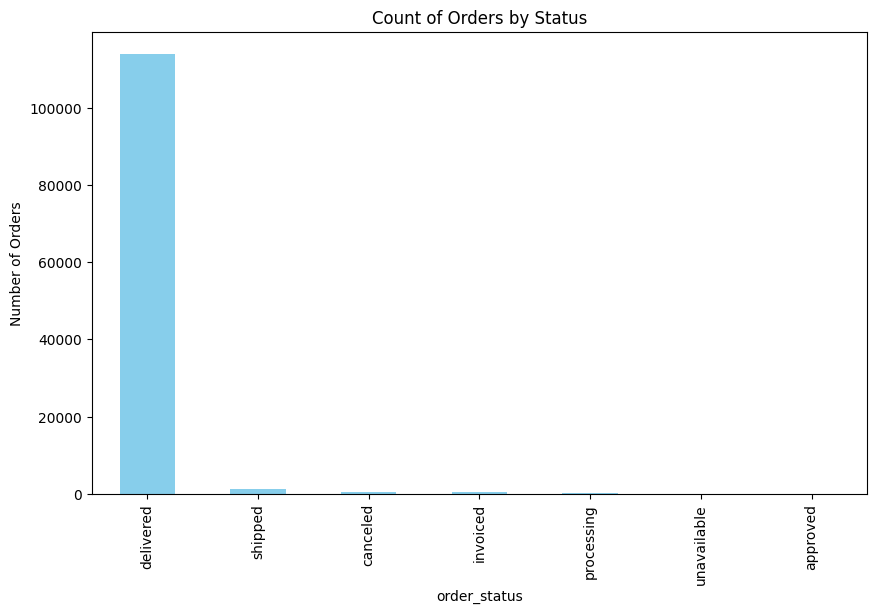

In [43]:
# Create a visualization to count the orders by statuses

df['order_status'].value_counts().plot(kind='bar', color='skyblue', figsize=(10,6))
plt.title('Count of Orders by Status')
plt.ylabel('Number of Orders')
plt.show()

### 2 - Evolution of total orders over time

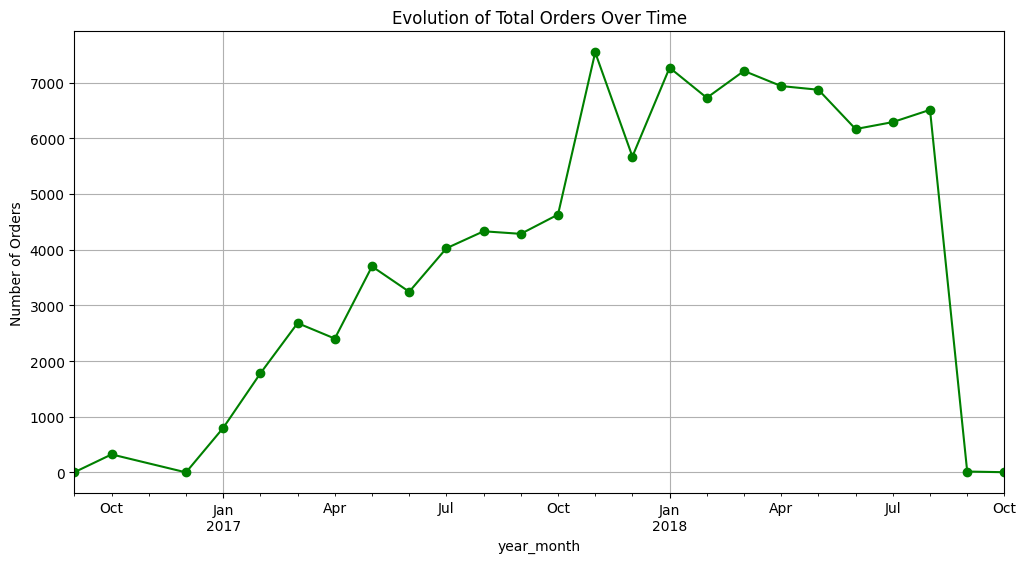

In [44]:
# Create a visualization to see the evolution of orders over time

# On groupe par 'year_month' et on compte les IDs de commandes
evolution = df.groupby('year_month')['order_id'].count()

# On trace une ligne 
evolution.plot(kind='line', marker='o', figsize=(12,6), color='green')
plt.title('Evolution of Total Orders Over Time')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()


### 3 - Comparing 2017 and 2018 (bonus)

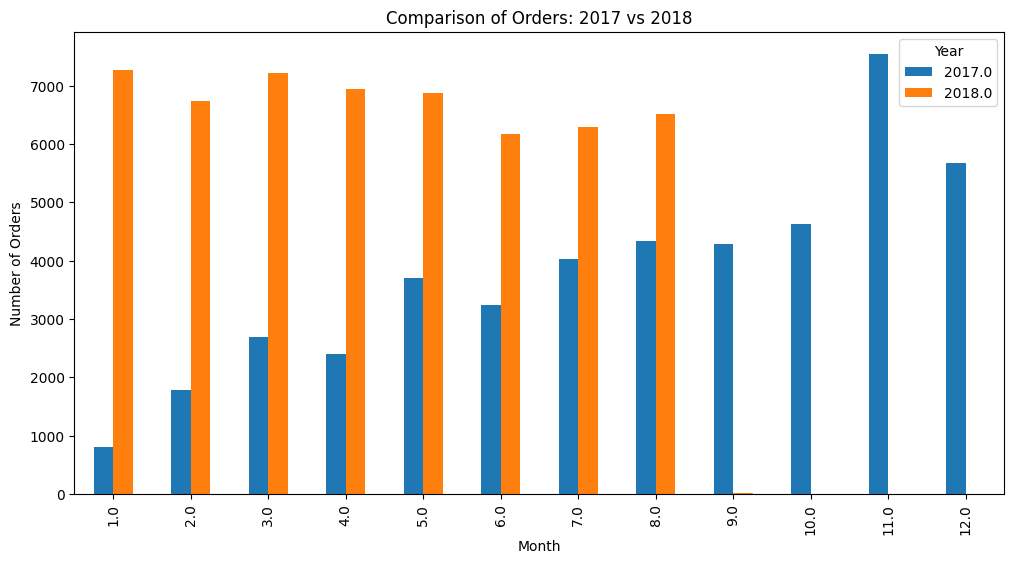

In [45]:
# Create a visualization to compare 2017 and 2018 on the same graph (bar charts with a "hue" = 'year'

# On crée un tableau croisé dynamique (pivot table) pour comparer les mois par année
comparison = df[df['year'].isin([2017, 2018])].pivot_table(index='month', columns='year', values='order_id', aggfunc='count')

# On affiche ça en barres groupées
comparison.plot(kind='bar', figsize=(12,6))
plt.title('Comparison of Orders: 2017 vs 2018')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend(title='Year')
plt.show()

## D - Delivery times

### 1 - Delivery time by product category

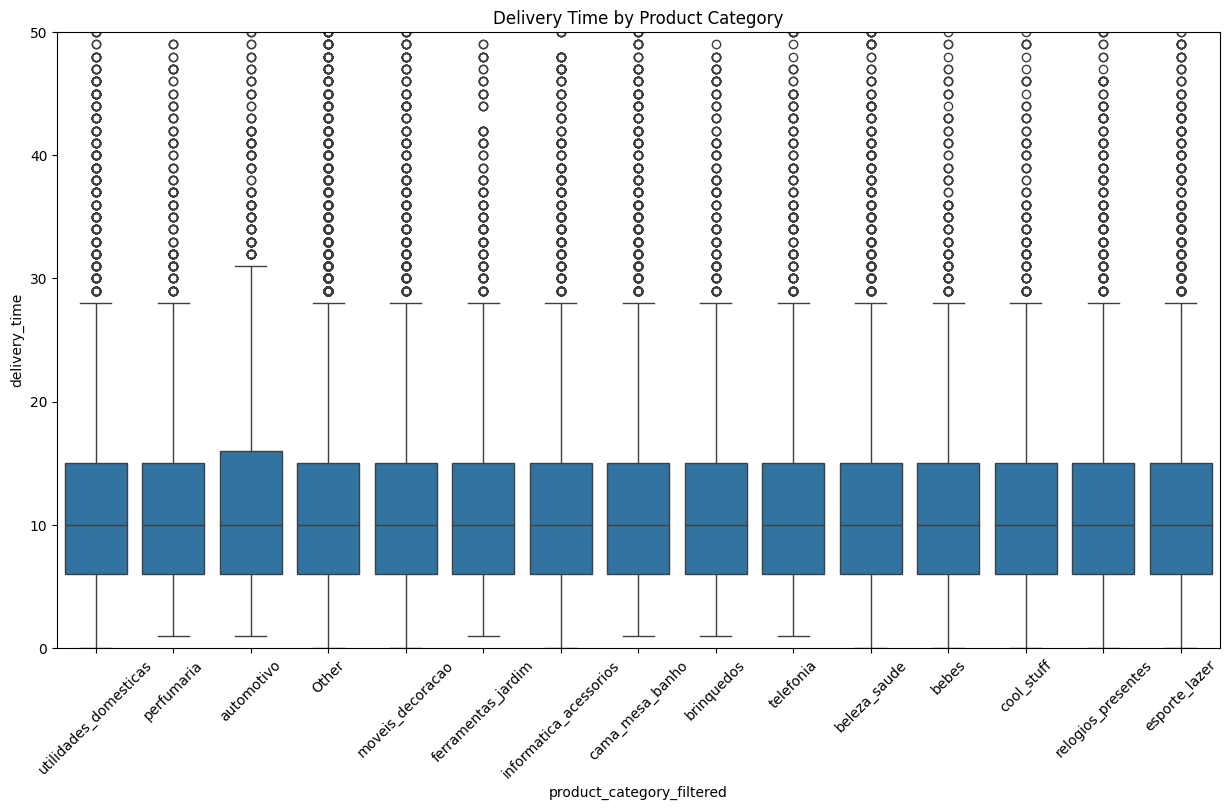

In [47]:
# Start by counting the orders by product category, and create an 'Other section' for product categories that have the lowest amount of orders

# 1. On compte les occurrences (on enlève les NaNs pour être sûr)
counts = df['product_category_name'].value_counts()

# 2. On crée la colonne filtrée en vérifiant si la valeur est bien du texte (pas un NaN)
threshold = 3000
df['product_category_filtered'] = df['product_category_name'].apply(
    lambda x: x if pd.notnull(x) and counts.get(x, 0) > threshold else 'Other'
)

# 3. Création du Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x='product_category_filtered', y='delivery_time')
plt.title('Delivery Time by Product Category')
plt.xticks(rotation=45)
plt.ylim(0, 50) 
plt.show()

Nombre de lignes avec un jour valide : 99441


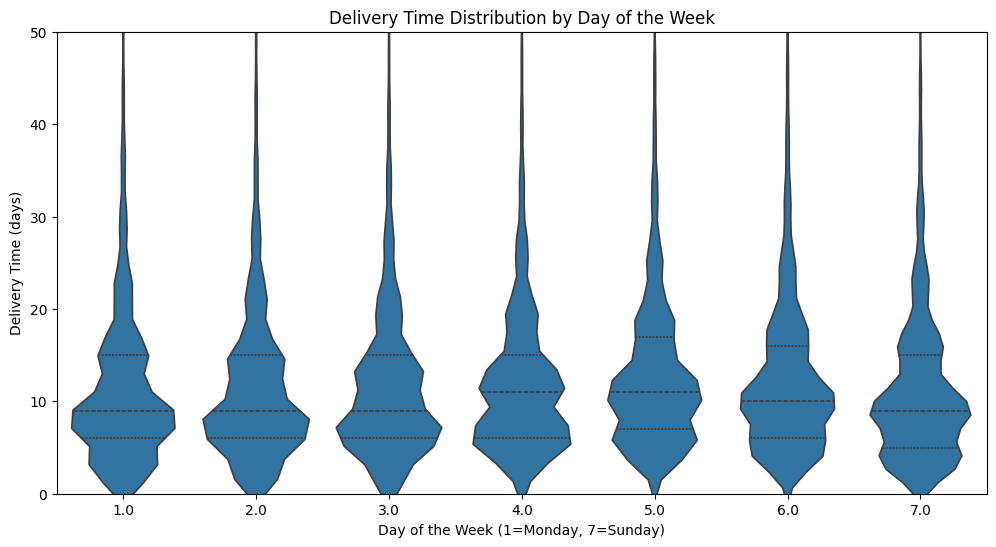

In [51]:
# Create a boxplot visualization that shows the delivery time by product category

# 1. On s'assure que la date est bien au bon format 
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

# 2. On recalcule le jour de la semaine (1=Lundi, 7=Dimanche)
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.dayofweek + 1

# 3. On vérifie qu'on a bien des données (on ne drop rien cette fois pour voir)
print(f"Nombre de lignes avec un jour valide : {df['day_of_week_int'].notnull().sum()}")

# 4. On trace le graphique
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[df['day_of_week_int'].notnull()], 
               x='day_of_week_int', 
               y='delivery_time', 
               inner="quartile")

plt.title('Delivery Time Distribution by Day of the Week')
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)')
plt.ylabel('Delivery Time (days)')
plt.ylim(0, 50) 
plt.show()

### 2 - Delivery time by day of the week

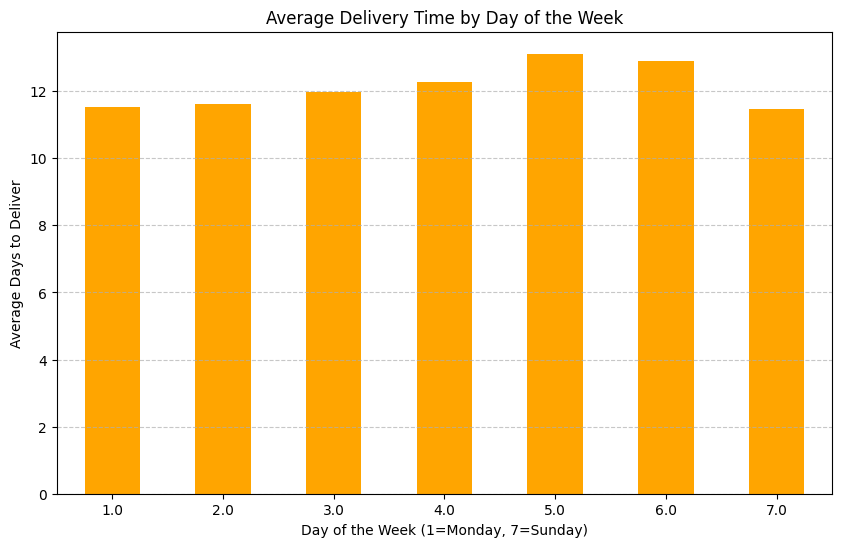

In [53]:
# Create a violin box plot visualization to see the delivery time by day of the week

df['day_of_week_int'] = pd.to_datetime(df['order_purchase_timestamp']).dt.dayofweek + 1

# 2. On calcule la moyenne du délai de livraison par jour
weekday_delivery = df.groupby('day_of_week_int')['delivery_time'].mean()

# 3. Affichage en barres pour bien comparer les jours
weekday_delivery.plot(kind='bar', color='orange', figsize=(10, 6))

plt.title('Average Delivery Time by Day of the Week')
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)')
plt.ylabel('Average Days to Deliver')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 3 - Average delivery time by month  (bonus)

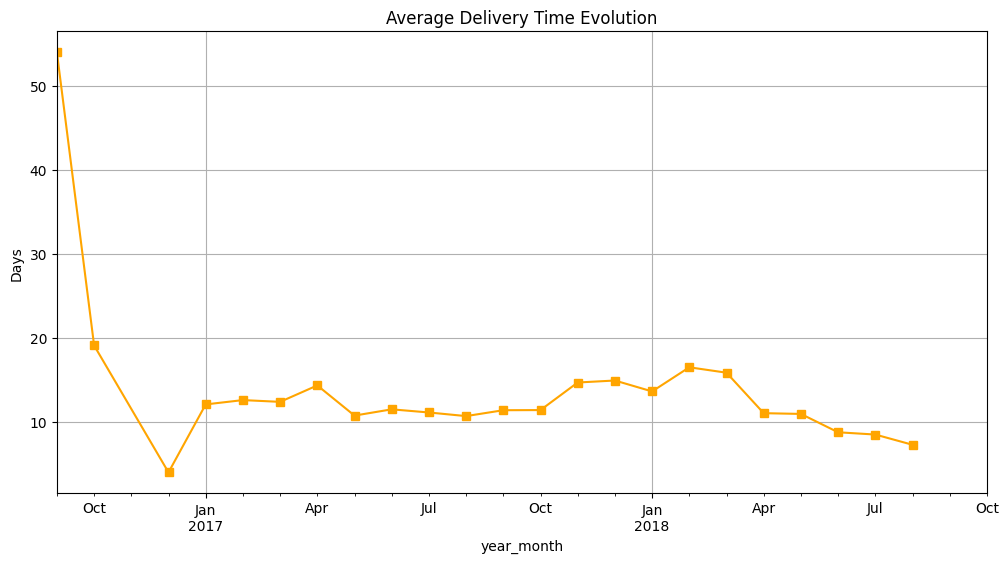

In [52]:
# Create barplot for the monthly average delivery time

# Calcul de la moyenne par mois
monthly_delivery = df.groupby('year_month')['delivery_time'].mean()

# Affichage en ligne
monthly_delivery.plot(kind='line', marker='s', color='orange', figsize=(12, 6))
plt.title('Average Delivery Time Evolution')
plt.ylabel('Days')
plt.grid(True)
plt.show()


## E - Bonus

### 1 - Order distribution by day of week and time of day 

/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_1744/858962938.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_of_week_int', palette='viridis')


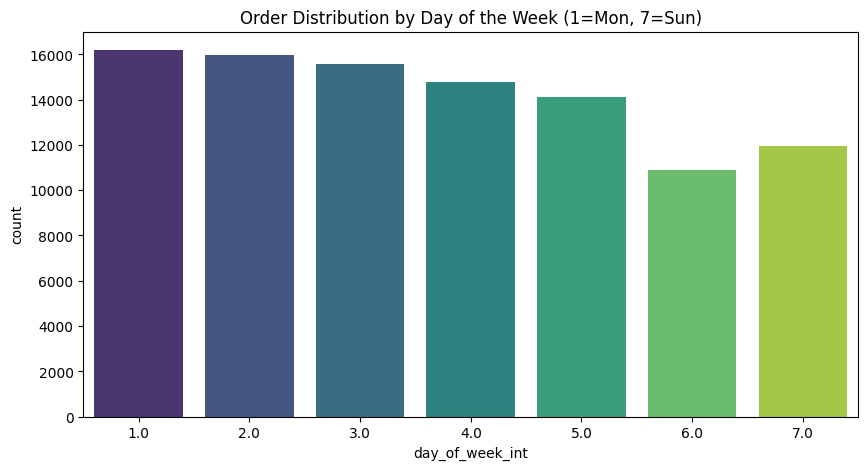

In [54]:
# Count plot showing order distribution by day of week

# Distribution par jour de la semaine
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='day_of_week_int', palette='viridis')
plt.title('Order Distribution by Day of the Week (1=Mon, 7=Sun)')
plt.show()




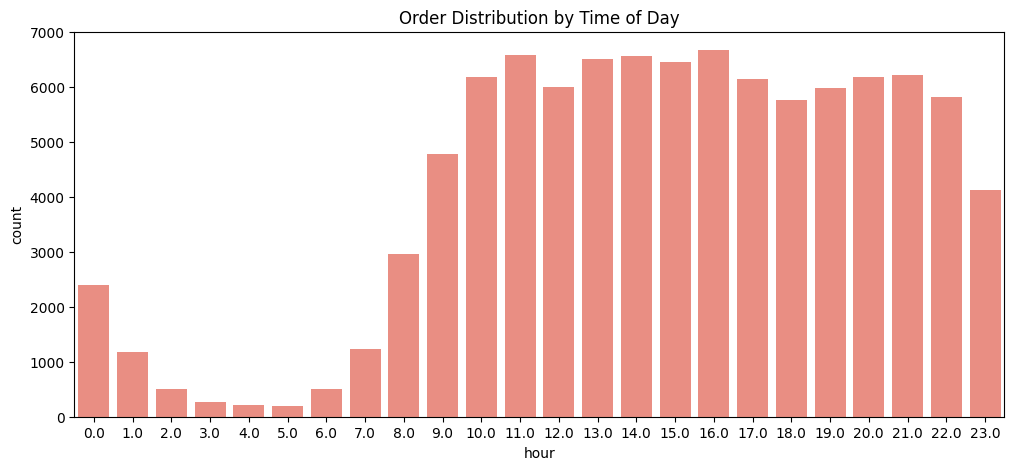

In [55]:
# Count plot showing order distribution by time of day

# Distribution par heure de la journée
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hour', color='salmon')
plt.title('Order Distribution by Time of Day')
plt.show()

### 2 - Payments

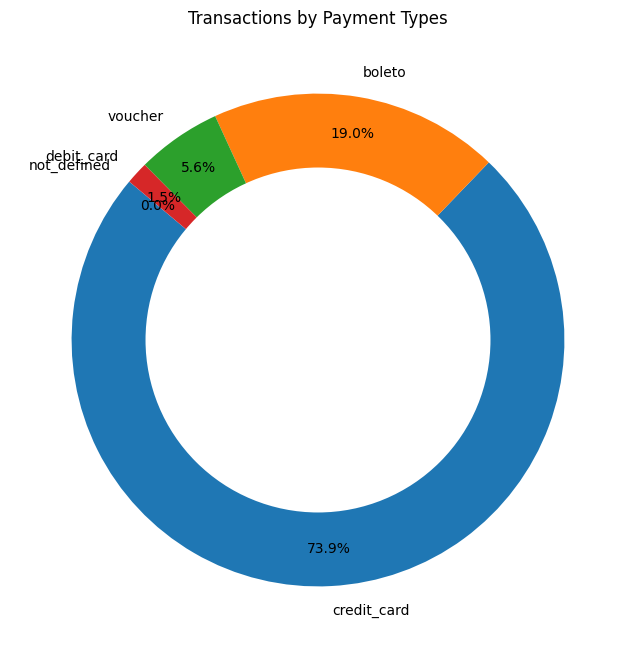

In [56]:
# Create a donut (pie chart) that show transactions by payment types

# Préparation des données de paiement
payment_counts = df_order_payments['payment_type'].value_counts()

# Création du Donut Chart
plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
center_circle = plt.Circle((0,0), 0.70, fc='white') # Le trou du donut
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Transactions by Payment Types')
plt.show()



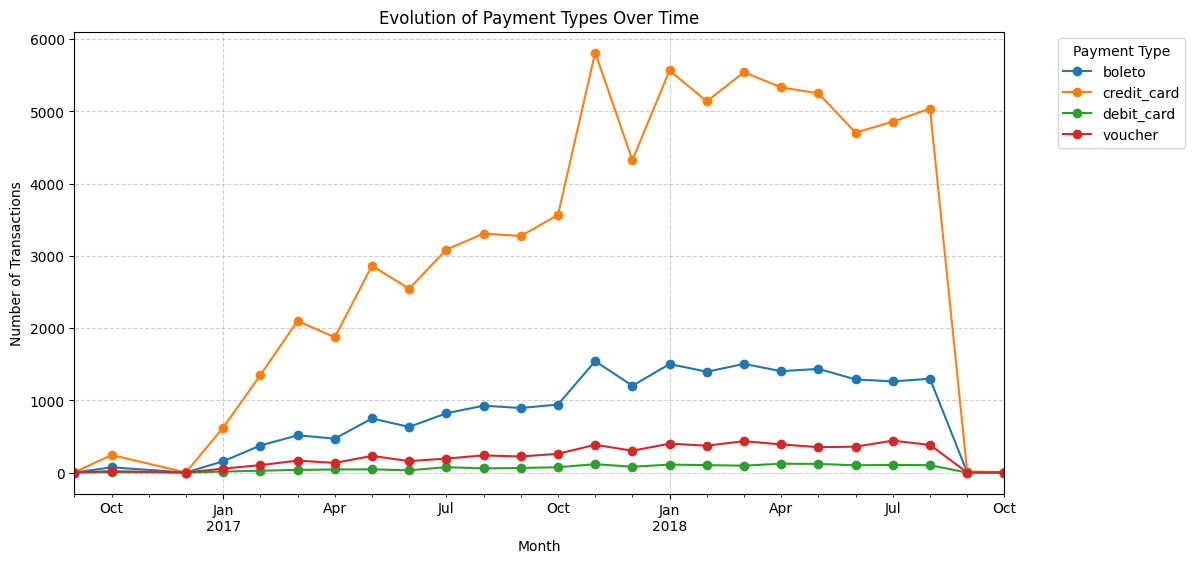

In [58]:
# Show the evolution of payment types over time

# 1. On merge les paiements avec notre dataframe principal (qui a déjà les dates)
df_pay_evolution = df[['order_id', 'year_month']].merge(df_order_payments[['order_id', 'payment_type']], on='order_id')

# 2. On crée le tableau croisé pour compter les types de paiement par mois
pay_evolution = df_pay_evolution.groupby(['year_month', 'payment_type']).size().unstack().fillna(0)

# 3. On affiche le graphique
pay_evolution.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Evolution of Payment Types Over Time')
plt.ylabel('Number of Transactions')
plt.xlabel('Month')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### 3 - Geolocation

In [60]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]


In [63]:
%who DataFrame

comparison	 correlation	 correlation_features	 data_info	 df	 df_clean_days	 df_customer	 df_filtered	 df_geolocation	 
df_merged	 df_order_items	 df_order_payments	 df_order_reviews	 df_orders	 df_pay_evolution	 df_products	 df_sellers	 df_sp	 
pay_evolution	 


In [64]:
# Create a heatmap of all orders by location using an API to retrieve the latitude and longitude of every location, and display them on a map

# 1. On utilise 'df_customer' 
df_with_geo = df.merge(df_customer[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left')

# 2. On merge avec la table de géolocalisation
geo_data = df_with_geo.merge(df_geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']], 
                            left_on='customer_zip_code_prefix', 
                            right_on='geolocation_zip_code_prefix', 
                            how='left')

# 3. Création de la carte
import folium
from folium.plugins import HeatMap

# On nettoie et on prend un échantillon pour que ça charge vite
df_map = geo_data[['geolocation_lat', 'geolocation_lng']].dropna().sample(2000)
map_brazil = folium.Map(location=[-15.78, -47.93], zoom_start=4)

# On ajoute les données
HeatMap(df_map.values.tolist()).add_to(map_brazil)

map_brazil

### 4 - Profit computation

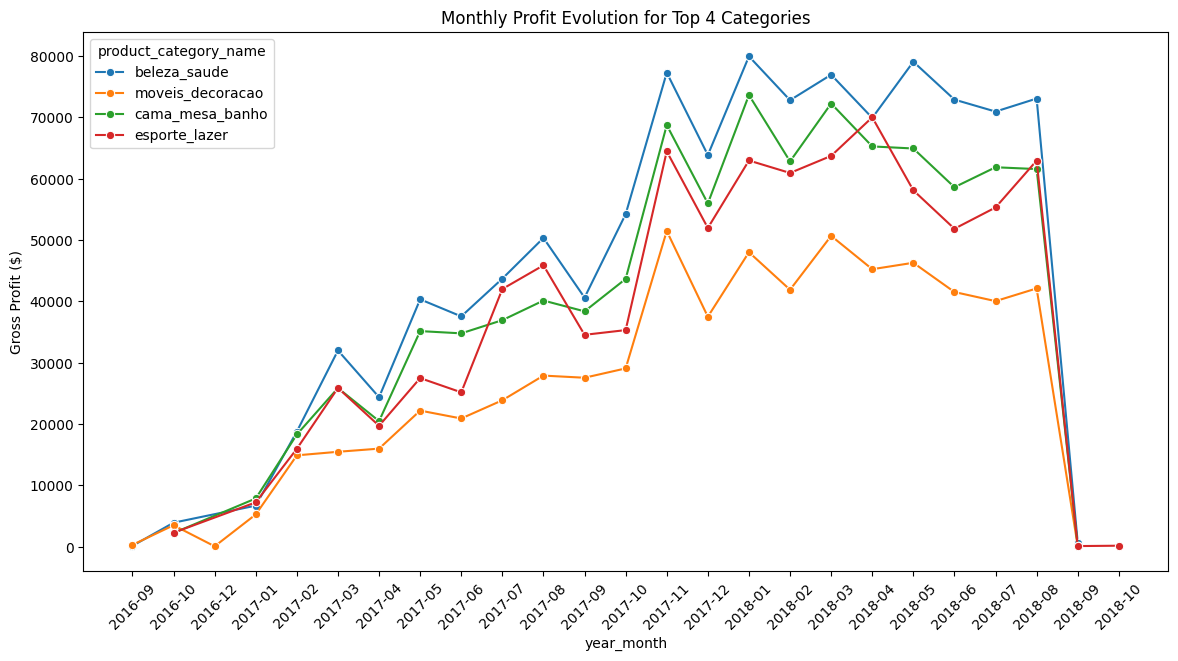

In [65]:
# Show the monthly profit evolution for the best 4 product categories
# x axis: months
# y axis: gross profit (payment value - total order value)
# hue : top product categories

# 1. On identifie les 4 meilleures catégories en termes de volume
top_4_categories = df['product_category_name'].value_counts().nlargest(4).index

# 2. On filtre le dataframe pour ces 4 catégories
df_profit = df[df['product_category_name'].isin(top_4_categories)].copy()

# 3. Calcul du profit (on simplifie selon ta consigne)
# Note : Dans Olist, payment_value inclut souvent le freight_value
df_profit['gross_profit'] = df_profit['price'] # Adapté selon ta définition exacte en cours

# 4. Évolution mensuelle
profit_evolution = df_profit.groupby(['year_month', 'product_category_name'])['gross_profit'].sum().reset_index()

# 5. Affichage
plt.figure(figsize=(14, 7))
sns.lineplot(data=profit_evolution, x=profit_evolution['year_month'].astype(str), 
             y='gross_profit', hue='product_category_name', marker='o')
plt.title('Monthly Profit Evolution for Top 4 Categories')
plt.xticks(rotation=45)
plt.ylabel('Gross Profit ($)')
plt.show()
